### 数据集

In [149]:
import numpy as np
import matplotlib.pyplot as plt

In [150]:
w, b = 1.8, 2.5  # 设置线性关系参数：w 为斜率，b 为截距

In [151]:
np.random.seed(0)              # 固定随机种子，保证每次运行生成相同的随机数据
x1 = np.random.rand(100) * 4   # 生成 100 个 0~4 之间的随机数，作为第一个特征 x1
noise = np.random.randn(100)   # 生成 100 个服从标准正态分布的随机噪声
x2 = w * x1 + b + noise        # 根据线性关系 x2 = w*x1 + b + noise 生成第二个特征

In [152]:
x1.shape, x2.shape

((100,), (100,))

In [153]:
x = np.vstack([x1, x2]).T      # 将 x1 和 x2 按行堆叠，再转置为 100 行 2 列的数据集
x.shape

(100, 2)

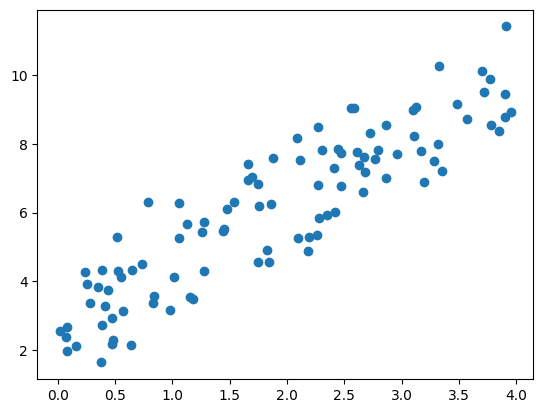

In [154]:
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [155]:
np.mean(x, axis=0)  # 按列计算 x 的平均值

array([1.89117536, 6.09644999])

In [156]:
x -= np.mean(x, axis=0)  # 零均值化

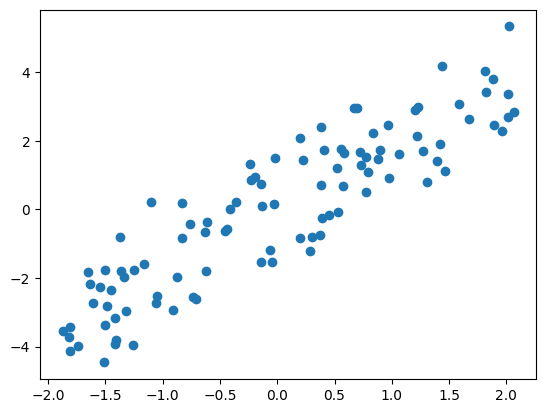

In [157]:
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [158]:
np.mean(x, axis=0)  # 按列计算 x 的平均值

array([-1.39888101e-16,  1.49658064e-15])

### PCA

In [159]:
from sklearn.decomposition import PCA

In [160]:
pca = PCA(n_components=1)
pca.fit(x);

In [161]:
pca.components_  # 查看 PCA 学习得到的主成分方向

array([[0.42746553, 0.90403165]])

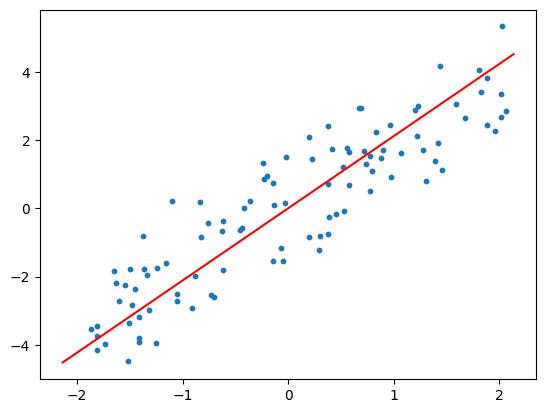

In [162]:
plt.scatter(x[:, 0], x[:, 1], s=10)
plt.plot(  # 绘制第一主成分方向
    np.array([pca.components_[0][0] * -1, pca.components_[0][0]]) * 5,
    np.array([pca.components_[0][1] * -1, pca.components_[0][1]]) * 5,
    c='r')
plt.show()

In [163]:
x_pca = pca.transform(x)  # 使用已经训练好的 PCA 将二维数据降维到一维
x_pca.shape

(100, 1)

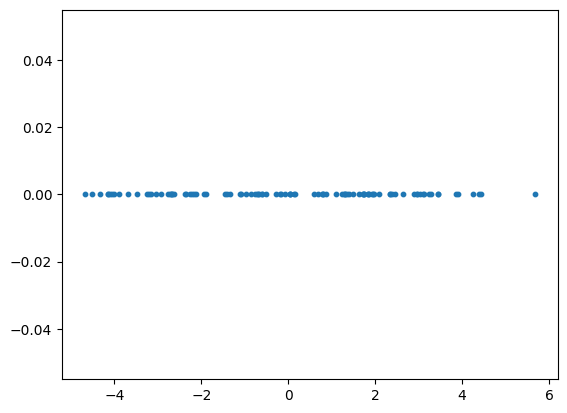

In [164]:
plt.scatter(x_pca, np.zeros_like(x_pca), s=10)
plt.show()

In [165]:
x_pca_inv = pca.inverse_transform(x_pca)  # 将降维后的一维数据转换回原来的二维特征空间

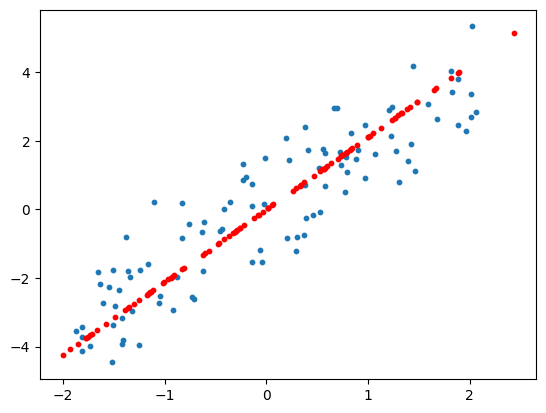

In [166]:
# 绘制 PCA 降维后再恢复到二维空间的数据，红色点表示经过 inverse_transform 恢复后的数据
plt.scatter(x[:, 0], x[:, 1], s=10)
plt.scatter(x_pca_inv[:, 0], x_pca_inv[:, 1], s=10, c='r')
plt.show()